In [1]:
from pathlib import Path
import json
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_DIR = Path.cwd()

model_notebooks = {
    "Custom CNN": "02_custom_cnn.ipynb",
    "ResNet-18": "01_resnet18_baseline.ipynb.ipynb",
    "DenseNet-121": "03_densenet121.ipynb",
    "EfficientNet-B0": "04_EfficientNet-B0.ipynb",
    "MobileNetV3-Large": "05_mobilenet_v3_large.ipynb",
}


def get_notebook_output_text(notebook_path):
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    text_parts = []

    for cell in notebook["cells"]:
        for output in cell.get("outputs", []):
            text = output.get("text", "")
            if isinstance(text, list):
                text = "".join(text)

            plain_text = output.get("data", {}).get("text/plain", "")
            if isinstance(plain_text, list):
                plain_text = "".join(plain_text)

            text_parts.extend([text, plain_text])

    return "\n".join(text_parts)


def get_last_metric(output_text, metric_name):
    pattern = rf"^{re.escape(metric_name)}\s+([0-9.]+)"
    matches = re.findall(pattern, output_text, flags=re.MULTILINE)

    if not matches:
        raise ValueError(f"Could not find '{metric_name}' in notebook output.")

    return float(matches[-1])


rows = []

for model_name, notebook_name in model_notebooks.items():
    output_text = get_notebook_output_text(PROJECT_DIR / notebook_name)

    rows.append(
        {
            "Model": model_name,
            "Accuracy": get_last_metric(output_text, "Accuracy"),
            "Balanced Accuracy": get_last_metric(output_text, "Balanced accuracy"),
            "Precision": get_last_metric(output_text, "Precision"),
            "Sensitivity": get_last_metric(output_text, "Recall / Sensitivity"),
            "Specificity": get_last_metric(output_text, "Specificity"),
            "F1-score": get_last_metric(output_text, "F1 score"),
            "ROC-AUC": get_last_metric(output_text, "ROC-AUC"),
            "PR-AUC": get_last_metric(output_text, "PR-AUC"),
        }
    )

slice_level_results = pd.DataFrame(rows)

display(
    slice_level_results.style.format(
        "{:.4f}",
        subset=slice_level_results.columns[1:],
    )
)

,Model,Accuracy,Balanced Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC,PR-AUC
0,Custom CNN,0.6521,0.5000,0.0000,0.0000,1.0000,0.0000,0.5571,0.4881
1,ResNet-18,0.7050,0.6905,0.5672,0.6429,0.7382,0.6026,0.7508,0.7051
2,DenseNet-121,0.6710,0.6886,0.5190,0.7462,0.6309,0.6122,0.7603,0.7218
3,EfficientNet-B0,0.7423,0.7235,0.6219,0.6617,0.7854,0.6412,0.7729,0.7577
4,MobileNetV3-Large,0.7253,0.6995,0.6033,0.6147,0.7844,0.6089,0.7349,0.7387


In [4]:
def get_last_metric_with_colon(output_text, metric_name):
    pattern = rf"^{re.escape(metric_name)}\s*:?\s*([0-9.]+)"
    matches = re.findall(pattern, output_text, flags=re.MULTILINE)

    if not matches:
        raise ValueError(f"Could not find '{metric_name}' in notebook output.")

    return float(matches[-1])


bilstm_output = get_notebook_output_text(
    PROJECT_DIR / "07_resnet18_lstm.ipynb"
)

scan_level_results = pd.DataFrame(
    [
        {
            "Model": "ResNet-18 + BiLSTM",
            "Accuracy": get_last_metric_with_colon(bilstm_output, "Accuracy"),
            "Balanced Accuracy": get_last_metric_with_colon(
                bilstm_output,
                "Balanced accuracy",
            ),
            "Precision": get_last_metric_with_colon(bilstm_output, "Precision"),
            "Sensitivity": get_last_metric_with_colon(
                bilstm_output,
                "Sensitivity / recall",
            ),
            "Specificity": get_last_metric_with_colon(
                bilstm_output,
                "Specificity",
            ),
            "F1-score": get_last_metric_with_colon(bilstm_output, "F1-score"),
            "ROC-AUC": get_last_metric_with_colon(
                bilstm_output,
                "Test ROC-AUC",
            ),
            "PR-AUC": get_last_metric_with_colon(bilstm_output, "PR-AUC"),
        }
    ]
)

display(
    scan_level_results.style.format(
        "{:.4f}",
        subset=scan_level_results.columns[1:],
    )
)

,Model,Accuracy,Balanced Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC,PR-AUC
0,ResNet-18 + BiLSTM,0.5556,0.5750,0.5000,0.7500,0.4000,0.6000,0.7000,0.7292


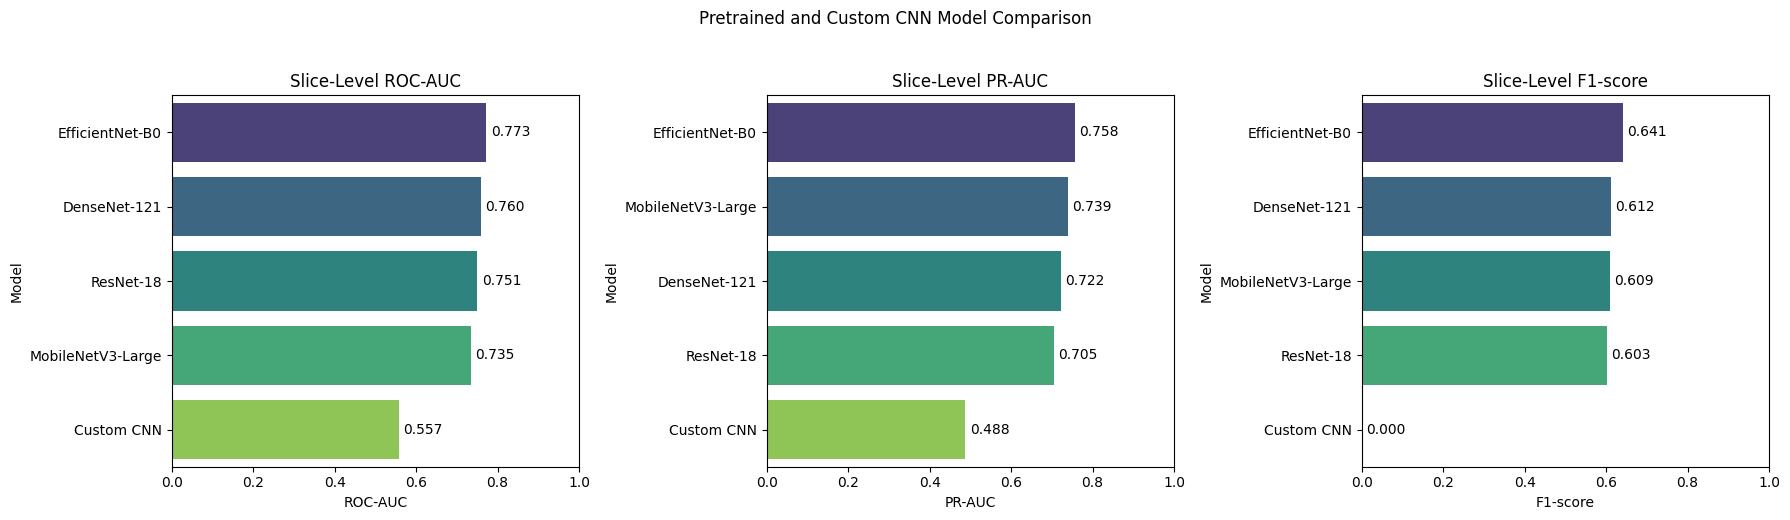

In [5]:
metrics_to_plot = ["ROC-AUC", "PR-AUC", "F1-score"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    plot_data = slice_level_results.sort_values(metric, ascending=False)

    sns.barplot(
        data=plot_data,
        x=metric,
        y="Model",
        hue="Model",
        palette="viridis",
        legend=False,
        ax=ax,
    )

    ax.set_title(f"Slice-Level {metric}")
    ax.set_xlim(0, 1)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)

plt.suptitle("Pretrained and Custom CNN Model Comparison", y=1.03)
plt.tight_layout()
plt.show()

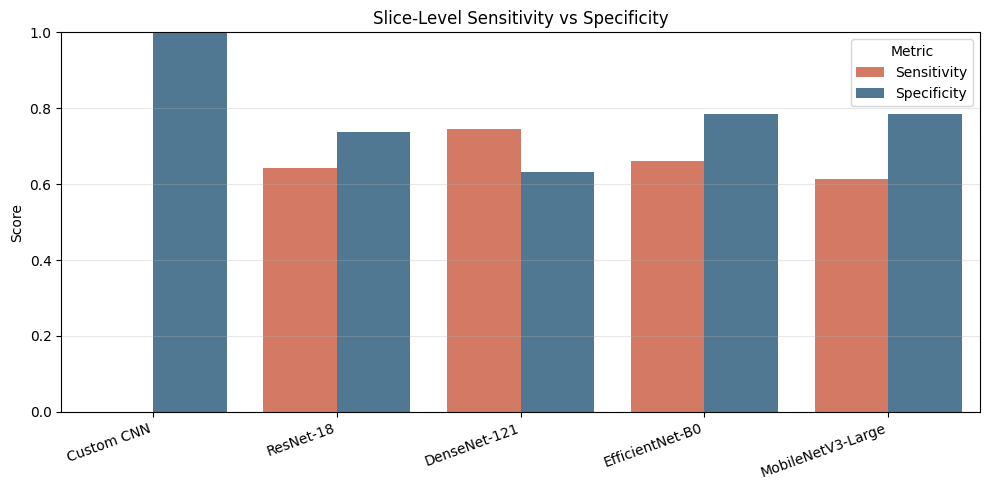

In [6]:
clinical_metrics = slice_level_results.melt(
    id_vars="Model",
    value_vars=["Sensitivity", "Specificity"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=clinical_metrics,
    x="Model",
    y="Score",
    hue="Metric",
    palette=["#e76f51", "#457b9d"],
)

plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Score")
plt.title("Slice-Level Sensitivity vs Specificity")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

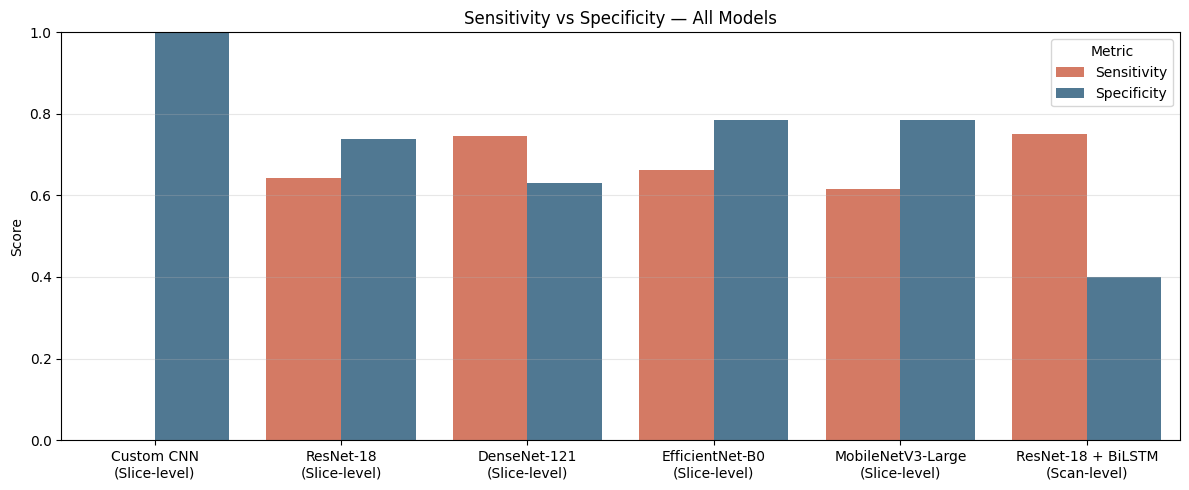

In [7]:
all_results = pd.concat(
    [
        slice_level_results.assign(**{"Evaluation Level": "Slice-level"}),
        scan_level_results.assign(**{"Evaluation Level": "Scan-level"}),
    ],
    ignore_index=True,
)

all_results["Model Label"] = (
    all_results["Model"]
    + "\n("
    + all_results["Evaluation Level"]
    + ")"
)

all_clinical_metrics = all_results.melt(
    id_vars=["Model Label", "Evaluation Level"],
    value_vars=["Sensitivity", "Specificity"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=all_clinical_metrics,
    x="Model Label",
    y="Score",
    hue="Metric",
    palette=["#e76f51", "#457b9d"],
)

plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Score")
plt.title("Sensitivity vs Specificity — All Models")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
comparison_overview = all_results[
    [
        "Model",
        "Evaluation Level",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
    ]
].copy()

display(
    comparison_overview.style.format(
        "{:.4f}",
        subset=comparison_overview.columns[2:],
    )
)

,Model,Evaluation Level,Accuracy,Balanced Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC,PR-AUC
0,Custom CNN,Slice-level,0.6521,0.5000,0.0000,0.0000,1.0000,0.0000,0.5571,0.4881
1,ResNet-18,Slice-level,0.7050,0.6905,0.5672,0.6429,0.7382,0.6026,0.7508,0.7051
2,DenseNet-121,Slice-level,0.6710,0.6886,0.5190,0.7462,0.6309,0.6122,0.7603,0.7218
3,EfficientNet-B0,Slice-level,0.7423,0.7235,0.6219,0.6617,0.7854,0.6412,0.7729,0.7577
4,MobileNetV3-Large,Slice-level,0.7253,0.6995,0.6033,0.6147,0.7844,0.6089,0.7349,0.7387
5,ResNet-18 + BiLSTM,Scan-level,0.5556,0.5750,0.5000,0.7500,0.4000,0.6000,0.7000,0.7292


In [9]:
best_slice_auc = slice_level_results.loc[
    slice_level_results["ROC-AUC"].idxmax()
]

best_slice_f1 = slice_level_results.loc[
    slice_level_results["F1-score"].idxmax()
]

best_slice_sensitivity = slice_level_results.loc[
    slice_level_results["Sensitivity"].idxmax()
]

scan_model = scan_level_results.iloc[0]

print(
    f"Best slice-level ROC-AUC: {best_slice_auc['Model']} "
    f"({best_slice_auc['ROC-AUC']:.4f})"
)

print(
    f"Best slice-level F1-score: {best_slice_f1['Model']} "
    f"({best_slice_f1['F1-score']:.4f})"
)

print(
    f"Highest slice-level sensitivity: {best_slice_sensitivity['Model']} "
    f"({best_slice_sensitivity['Sensitivity']:.4f})"
)

print(
    f"Scan-level model: {scan_model['Model']} | "
    f"ROC-AUC = {scan_model['ROC-AUC']:.4f} | "
    f"Sensitivity = {scan_model['Sensitivity']:.4f}"
)

Best slice-level ROC-AUC: EfficientNet-B0 (0.7729)
Best slice-level F1-score: EfficientNet-B0 (0.6412)
Highest slice-level sensitivity: DenseNet-121 (0.7462)
Scan-level model: ResNet-18 + BiLSTM | ROC-AUC = 0.7000 | Sensitivity = 0.7500


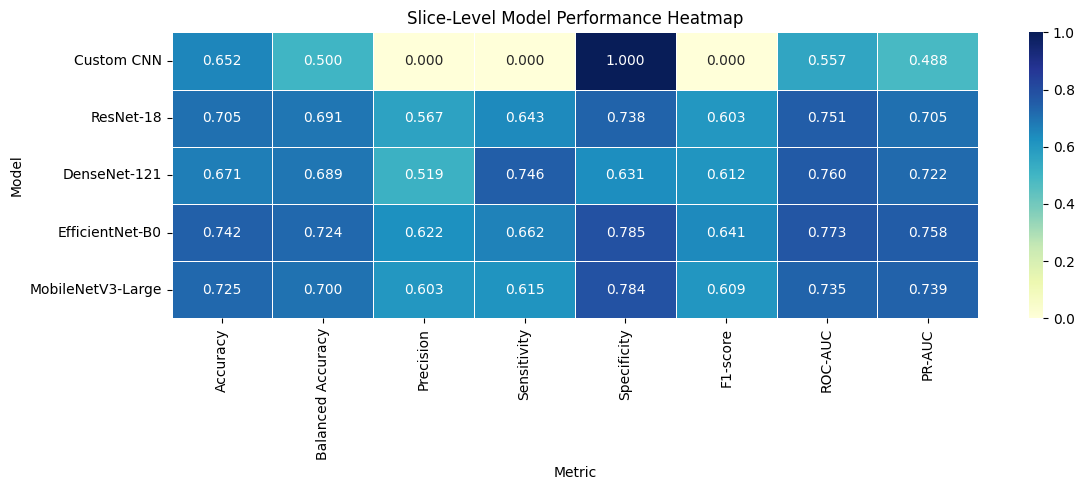

In [10]:
heatmap_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "ROC-AUC",
    "PR-AUC",
]

heatmap_data = slice_level_results.set_index("Model")[heatmap_metrics]

plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)

plt.title("Slice-Level Model Performance Heatmap")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [14]:
def extract_training_history(model_name, notebook_name):
    output_text = get_notebook_output_text(PROJECT_DIR / notebook_name)

    pattern = (
        r"Epoch (\d+)/\d+ \| "
        r"Train loss: ([0-9.]+) \| "
        r"Validation loss: ([0-9.]+) \| "
        r"Validation AUC: ([0-9.]+)"
    )

    matches = re.findall(pattern, output_text)

    if not matches:
        raise ValueError(f"Could not find epoch history for {model_name}.")

    return pd.DataFrame(
        [
            {
                "Model": model_name,
                "Epoch": int(epoch),
                "Train Loss": float(train_loss),
                "Validation Loss": float(validation_loss),
                "Validation AUC": float(validation_auc),
            }
            for epoch, train_loss, validation_loss, validation_auc in matches
        ]
    )


training_histories = pd.concat(
    [
        extract_training_history(model_name, notebook_name)
        for model_name, notebook_name in model_notebooks.items()
    ],
    ignore_index=True,
)

display(training_histories.head())

,Model,Epoch,Train Loss,Validation Loss,Validation AUC
0,Custom CNN,1,0.6842,0.7506,0.6060
1,Custom CNN,2,0.6498,1.3165,0.6836
2,Custom CNN,3,0.6054,1.8502,0.3530
3,Custom CNN,4,0.5754,1.3261,0.6095
4,Custom CNN,5,0.5491,1.7819,0.5327


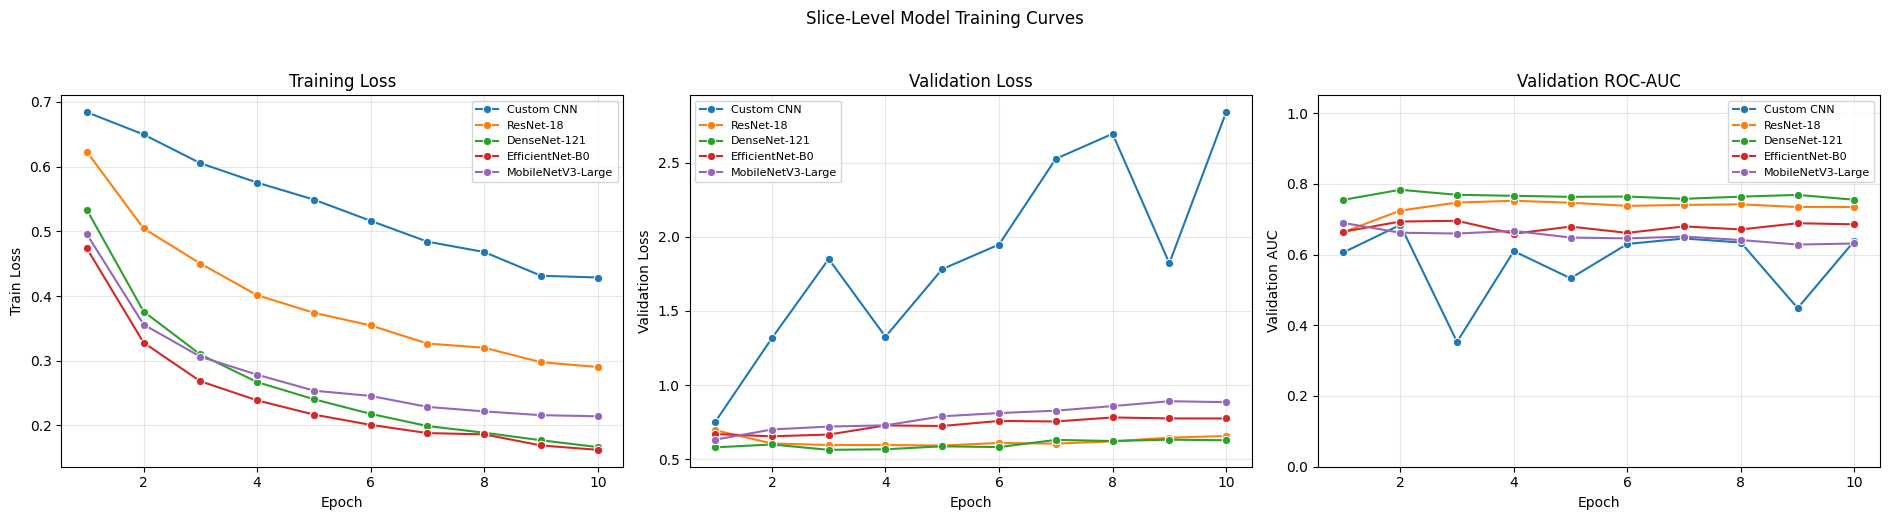

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.lineplot(
    data=training_histories,
    x="Epoch",
    y="Train Loss",
    hue="Model",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Training Loss")
axes[0].grid(alpha=0.3)

sns.lineplot(
    data=training_histories,
    x="Epoch",
    y="Validation Loss",
    hue="Model",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Validation Loss")
axes[1].grid(alpha=0.3)

sns.lineplot(
    data=training_histories,
    x="Epoch",
    y="Validation AUC",
    hue="Model",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Validation ROC-AUC")
axes[2].set_ylim(0, 1.05)
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.legend(fontsize=8)

plt.suptitle("Slice-Level Model Training Curves", y=1.03)
plt.tight_layout()
plt.show()